In [1]:
import sys

sys.path.append("..")

import pandas as pd
import numpy as np

from sklearn.neighbors import NearestNeighbors

from src.graph.node2vec_embeddings import generate_embeddings

c:\Users\anand\GeoValNet\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/raw/kc_house_data.csv")

In [3]:
coords = df[["lat", "long"]]

knn = NearestNeighbors(
    n_neighbors=10
)

knn.fit(coords)

distances, indices = knn.kneighbors(coords)

In [7]:
embeddings = generate_embeddings(
    indices,
    dimensions=32,
    walk_length=5,
    num_walks=10
)

Computing transition probabilities: 100%|██████████| 21613/21613 [00:10<00:00, 2122.42it/s]


In [8]:
print(embeddings.shape)

(21613, 32)


In [9]:
np.save(
    "../data/processed/embeddings_k10.npy",
    embeddings
)

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap

c:\Users\anand\GeoValNet\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/raw/kc_house_data.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
embeddings = np.load("../data/processed/embeddings_k10.npy")

print(embeddings.shape)

(21613, 32)


In [4]:
reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)

print(embedding_2d.shape)

c:\Users\anand\GeoValNet\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(21613, 2)


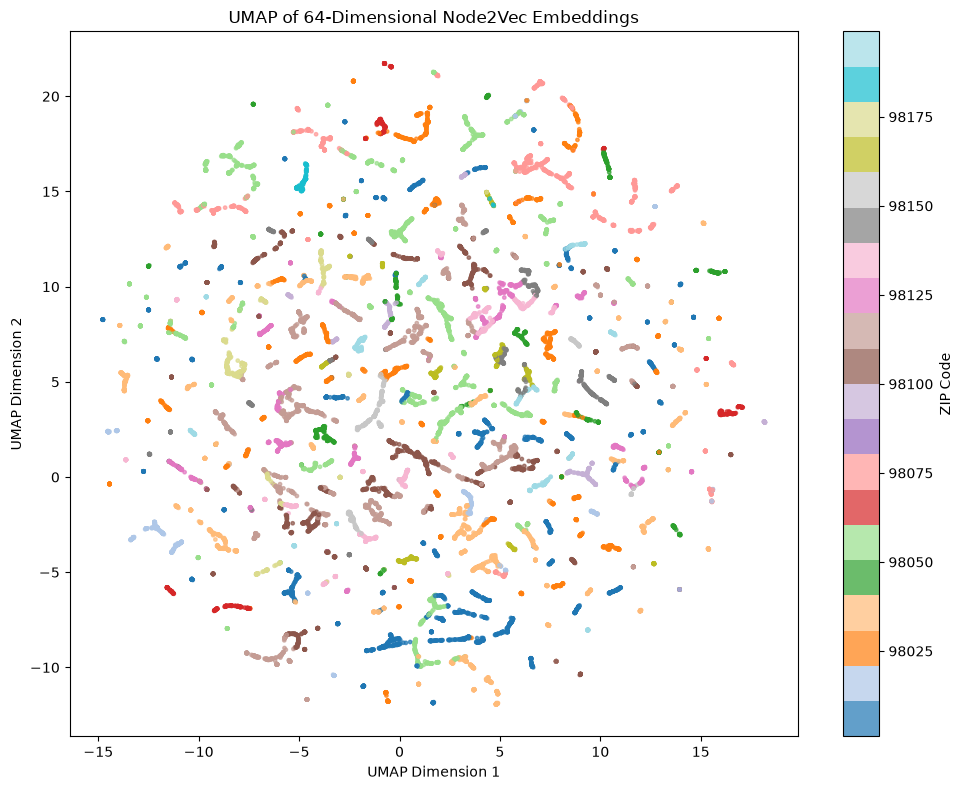

In [7]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=df["zipcode"],
    cmap="tab20",
    s=6,
    alpha=0.7
)

plt.title("UMAP of 64-Dimensional Node2Vec Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.colorbar(scatter, label="ZIP Code")

plt.tight_layout()

plt.savefig(
    "../reports/figures/umap_embeddings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
import os

print(os.listdir("../reports/figures"))

['residual_distribution.png', 'residual_plot.png', 'shap_bar.png', 'shap_beeswarm.png', 'shap_summary.png', 'umap_embeddings.png']


In [9]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [10]:
sample_embeddings = embeddings[:100]

In [11]:
similarity_matrix = cosine_similarity(sample_embeddings)

print(similarity_matrix.shape)

(100, 100)


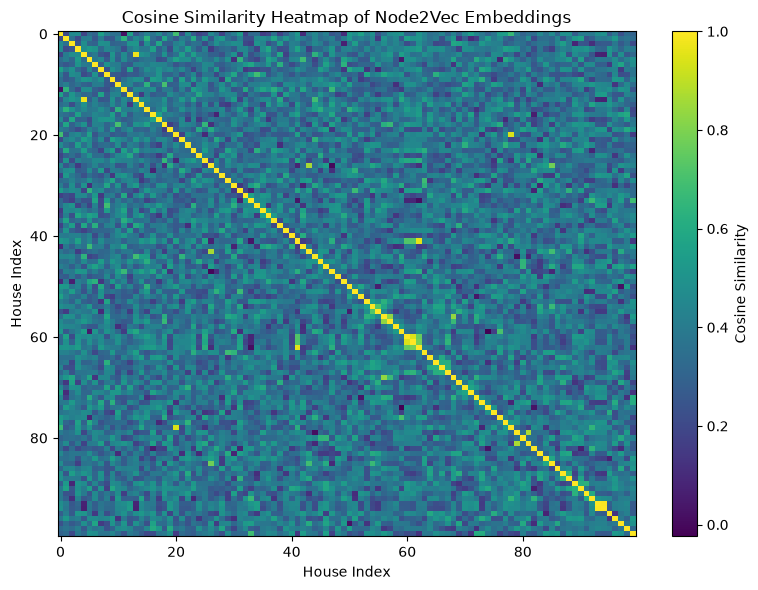

In [12]:
plt.figure(figsize=(8, 6))

plt.imshow(similarity_matrix, cmap="viridis", aspect="auto")

plt.colorbar(label="Cosine Similarity")

plt.title("Cosine Similarity Heatmap of Node2Vec Embeddings")

plt.xlabel("House Index")
plt.ylabel("House Index")

plt.tight_layout()

plt.show()

In [13]:
import numpy as np

mask = ~np.eye(similarity_matrix.shape[0], dtype=bool)

average_similarity = similarity_matrix[mask].mean()

print(f"Average Cosine Similarity: {average_similarity:.4f}")

Average Cosine Similarity: 0.3725


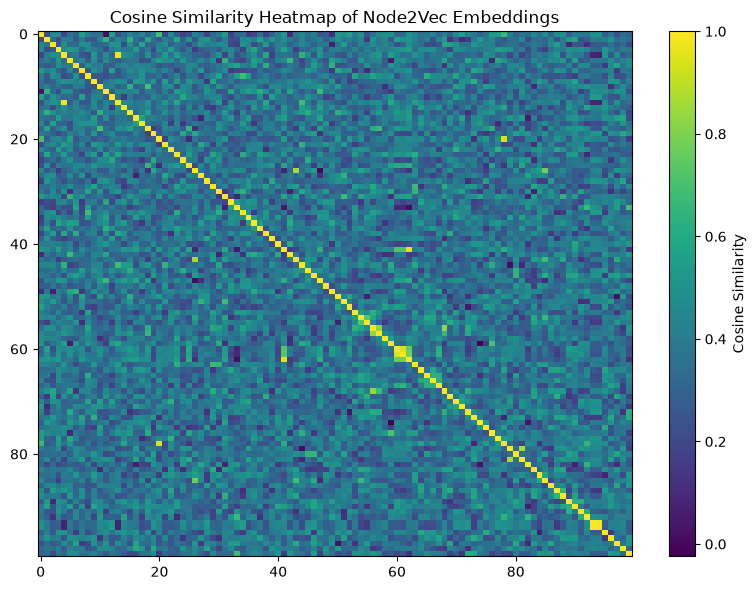

In [14]:
plt.figure(figsize=(8, 6))

plt.imshow(similarity_matrix, cmap="viridis", aspect="auto")

plt.colorbar(label="Cosine Similarity")

plt.title("Cosine Similarity Heatmap of Node2Vec Embeddings")

plt.tight_layout()

plt.savefig(
    "../reports/figures/cosine_similarity_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()